# 1D CNN for TAG Authentication — GPU-Accelerated (v3-GPU)

**Input**: Raw equalized signal `y/h` — vector of length 1024  
**Architecture**: 1D CNN (Chin & Chin, Eng. Proc. 2025) adapted for L=1024  
**Theory**: Braca et al. (2022) D3F framework — ML learns T^(n) converging to LLR  
**Threshold**: ROC → maximize PD subject to FPR ≤ α (Neyman-Pearson constrained)

**GPU improvements over v3 (CPU)**:
- Mixed precision (`float16`) via `tf.keras.mixed_precision`
- `tf.data.Dataset` pipeline with `prefetch` + parallel map
- XLA JIT compilation enabled globally
- Batch size tuned for GPU VRAM (512 vs 256)
- `MirroredStrategy` auto-detected for multi-GPU machines
- GPU memory growth enabled (avoids OOM on shared machines)

```
Input (1024, 1)
  → Conv1D(32, k=15) + BatchNorm + ReLU + MaxPool(4)   [→ 256, 32]
  → Conv1D(64,  k=9) + BatchNorm + ReLU + MaxPool(4)   [→  64, 64]
  → Conv1D(128, k=5) + BatchNorm + ReLU + GlobalAvgPool[→ 128]
  → Dense(64, ReLU) + Dropout(0.3)
  → Dense(1, Sigmoid, dtype=float32)  →  P(H1)
```

In [1]:
# ==============================================================================
# 1. IMPORTS & GPU CONFIGURATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

print(f"TensorFlow : {tf.__version__}")

# ── GPU: enable memory growth (must happen before any GPU ops) ──────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")

# Print detailed GPU info
for i, gpu in enumerate(gpus):
    print(f"  GPU {i}: {gpu}")

USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error enabling GPU memory growth: {e}")
        USE_GPU = False
else:
    print("⚠️  No GPU detected. Running on CPU (slower).")
    print("   For WSL GPU setup, see: https://www.tensorflow.org/install/gpu_wsl")

# ── Mixed precision: ONLY if GPU is available ─────────────────────────────
if USE_GPU:
    try:
        policy = keras.mixed_precision.Policy('mixed_float16')
        keras.mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy : {policy.name}")
    except Exception as e:
        print(f"⚠️  Error setting mixed precision: {e}")
        policy = keras.mixed_precision.Policy('float32')
        keras.mixed_precision.set_global_policy(policy)
        print(f"Fallback to policy : {policy.name}")
else:
    print("Mixed precision skipped (no GPU).")

# ── XLA JIT: DISABLED — causes 50+ min hangs on some GPU drivers ──────────
# CRITICAL FIX: XLA compilation on WSL/CUDA can trigger autotuner exhaustive
# search on first training step. This is a known TensorFlow/XLA issue.
# Mixed precision already provides 80% of GPU speedup without XLA risk.
# https://github.com/tensorflow/tensorflow/issues/57482
ENABLE_XLA = False

# Explicitly disable XLA globally
tf.config.optimizer.set_jit(ENABLE_XLA)
tf.config.run_functions_eagerly(False)  # Keep graph mode enabled

print(f"XLA JIT : disabled (avoids 50+ min autotuner hang)")
print(f"Graph mode : enabled (faster than eager)")

# ── Reproducibility ────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
notebook_dir       = Path.cwd()
project_root       = notebook_dir.parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "visualizations"
models_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

print(f"Data dir   : {data_dir}")
print(f"Models dir : {models_dir}")
print(f"Running on : {'GPU' if USE_GPU else 'CPU'}")

I0000 00:00:1783877487.671263   36939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783877487.726329   36939 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783877489.527311   36939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs found : 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ Memory growth enabled on 1 GPU(s).
Mixed precision policy : mixed_float16
XLA JIT : disabled (avoids 50+ min autotuner hang)
Graph mode : enabled (faster than eager)
Data dir   : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
Models dir : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
Running on : GPU


In [2]:
# ==============================================================================
# 2. LOAD DATASET — LAZY LOADING (evita OOM)
# ==============================================================================
# PROBLEMA ANTERIOR: f['train/z_eq'][:] carrega TUDO na memória RAM
#   (280k × 1024 × 4 bytes = 1.1 GB por dataset) → 6-7 GB total → OOM kill
#
# SOLUÇÃO: Usar HDF5 Dataset objects como generators para tf.data
# Tensorflow lê chunks sob demanda, mantendo RAM < 1.5 GB.

import psutil
import os

def print_memory_usage(label):
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024 / 1024  # MB
    avail = psutil.virtual_memory().available / 1024 / 1024
    print(f"  [{label:20s}] RAM: {mem:7.1f} MB | Available: {avail:7.1f} MB")

print_memory_usage("Start of Cell 2")

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(
        f"{dataset_path} not found.\nRun NN_01_DataGeneration.ipynb first."
    )

# ──────────────────────────────────────────────────────────────────────────────
# Load metadata ONLY — don't load data into memory yet
# ──────────────────────────────────────────────────────────────────────────────
with h5py.File(str(dataset_path), 'r') as f:
    if 'train/z_eq' not in f:
        raise KeyError(
            "z_eq não encontrado no dataset.\n"
            "Re-execute NN_01_DataGeneration.ipynb para regenerar o dataset com z_eq."
        )
    
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S   = float(f.attrs.get('RHO_S', 0.992472))
    RHO_T   = float(f.attrs.get('RHO_T', 0.212132))
    
    n_train = len(f['train/z_eq'])
    n_val   = len(f['val/z_eq'])
    n_test  = len(f['test/z_eq'])
    
    print(f"Dataset metadata loaded (no data in RAM):")
    print(f"  L_FIXED={L_FIXED}, RHO_S={RHO_S:.6f}, RHO_T={RHO_T:.6f}")
    print(f"  Train: {n_train} samples")
    print(f"  Val:   {n_val} samples")
    print(f"  Test:  {n_test} samples")

print_memory_usage("After metadata load")

# ──────────────────────────────────────────────────────────────────────────────
# Create HDF5 generator functions for lazy loading
# ──────────────────────────────────────────────────────────────────────────────

def load_h5_generator(h5_path, split, chunk_size=2000):
    """
    Generator that reads HDF5 dataset in chunks.
    Yields (z_eq[i], y[i]) tuples one sample at a time.
    """
    with h5py.File(str(h5_path), 'r') as f:
        z_data = f[f'{split}/z_eq']
        y_data = f[f'{split}/y']
        n_samples = len(z_data)
        
        for start_idx in range(0, n_samples, chunk_size):
            end_idx = min(start_idx + chunk_size, n_samples)
            z_chunk = z_data[start_idx:end_idx].astype(np.float32)
            y_chunk = y_data[start_idx:end_idx].astype(np.float32)
            
            for i in range(len(z_chunk)):
                yield z_chunk[i], y_chunk[i]

# Create tf.data Datasets from generators
print("Creating lazy-load datasets from HDF5...")
train_gen_ds = tf.data.Dataset.from_generator(
    lambda: load_h5_generator(dataset_path, 'train', chunk_size=2000),
    output_signature=(
        tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )
)

val_gen_ds = tf.data.Dataset.from_generator(
    lambda: load_h5_generator(dataset_path, 'val', chunk_size=2000),
    output_signature=(
        tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )
)

test_gen_ds = tf.data.Dataset.from_generator(
    lambda: load_h5_generator(dataset_path, 'test', chunk_size=2000),
    output_signature=(
        tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )
)

print(f"  ✓ Generators ready (data will load on-demand during training)")

print_memory_usage("After generator creation")

# ──────────────────────────────────────────────────────────────────────────────
# Validation: sample statistics from test set (loaded in chunks)
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n📊 Validation z_eq statistics (loading test set in chunks):")
with h5py.File(str(dataset_path), 'r') as f:
    z_test_raw = f['test/z_eq']
    y_test_arr = f['test/y'][:]
    snr_test_arr = f['test/snr'][:]
    
    for snr_lo in [0, 15, 25]:
        m1 = (y_test_arr == 1) & (snr_test_arr >= snr_lo) & (snr_test_arr < snr_lo + 5)
        m0 = (y_test_arr == 0) & (snr_test_arr >= snr_lo) & (snr_test_arr < snr_lo + 5)
        if m1.sum() > 50:
            v1 = z_test_raw[m1].var(axis=1).mean()
            v0 = z_test_raw[m0].var(axis=1).mean()
            print(f"  SNR [{snr_lo},{snr_lo+5}] dB: H1={v1:.5f}  H0={v0:.5f}  ratio={v1/(v0+1e-10):.2f}")

print_memory_usage("End of Cell 2")
print(f"\n✅ Cell 2 complete. Lazy datasets ready for Cell 3.")

  [Start of Cell 2     ] RAM:   897.6 MB | Available:  4358.4 MB
Dataset metadata loaded (no data in RAM):
  L_FIXED=1024, RHO_S=0.992472, RHO_T=0.212132
  Train: 280000 samples
  Val:   35000 samples
  Test:  35000 samples
  [After metadata load ] RAM:   898.7 MB | Available:  4358.3 MB
Creating lazy-load datasets from HDF5...


I0000 00:00:1783877490.349766   36939 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  ✓ Generators ready (data will load on-demand during training)
  [After generator creation] RAM:   992.7 MB | Available:  4266.5 MB

📊 Validation z_eq statistics (loading test set in chunks):
  SNR [0,5] dB: H1=0.40651  H0=0.40254  ratio=1.01
  SNR [15,20] dB: H1=0.02212  H0=0.01224  ratio=1.81
  SNR [25,30] dB: H1=0.01092  H0=0.00123  ratio=8.85
  [End of Cell 2       ] RAM:  1058.0 MB | Available:  4196.8 MB

✅ Cell 2 complete. Lazy datasets ready for Cell 3.


In [3]:
# ==============================================================================
# 3. tf.data PIPELINE  (GPU-optimised + LAZY LOADING)
# ==============================================================================
# The generators from Cell 2 are already tf.data.Dataset objects.
# Now we add batching, shuffling, and prefetching for GPU acceleration.
#
# Note: from_generator is slower than from_tensor_slices in terms of
# individual sample throughput, but avoids memory spikes. Prefetch + batching
# mitigate the speed penalty.

# Adaptive batch size based on GPU availability
if USE_GPU:
    BATCH_SIZE = 128  # Reduced from 256 for memory safety (6GB GPU + system RAM)
else:
    BATCH_SIZE = 64   # CPU: use smaller batch

AUTOTUNE = tf.data.AUTOTUNE

print(f"Batch size : {BATCH_SIZE} ({'GPU' if USE_GPU else 'CPU'})")
print_memory_usage("Start of Cell 3")

# ──────────────────────────────────────────────────────────────────────────────
# Prepare datasets: add batching, shuffling, prefetching
# ──────────────────────────────────────────────────────────────────────────────

def prepare_dataset(ds, n_samples, shuffle=False, batch_size=BATCH_SIZE):
    """Add batching, shuffling, and prefetching to a dataset."""
    
    if shuffle:
        # Use a reasonable shuffle buffer that fits in memory (~10k samples)
        buffer_size = min(10000, n_samples)
        ds = ds.shuffle(buffer_size=buffer_size, reshuffle_each_iteration=True, seed=42)
    
    # Batch
    ds = ds.batch(batch_size, drop_remainder=False)
    
    # Prefetch: overlap I/O and computation
    ds = ds.prefetch(AUTOTUNE)
    
    return ds

print("Preparing datasets with batching + prefetching...")
train_ds = prepare_dataset(train_gen_ds, n_train, shuffle=True,  batch_size=BATCH_SIZE)
val_ds   = prepare_dataset(val_gen_ds,   n_val,   shuffle=False, batch_size=BATCH_SIZE)
test_ds  = prepare_dataset(test_gen_ds,  n_test,  shuffle=False, batch_size=BATCH_SIZE)

# Estimate number of batches
n_batches_train = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
n_batches_val   = (n_val + BATCH_SIZE - 1) // BATCH_SIZE
n_batches_test  = (n_test + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Train batches : {n_batches_train} (total {n_train} samples)")
print(f"Val batches   : {n_batches_val} (total {n_val} samples)")
print(f"Test batches  : {n_batches_test} (total {n_test} samples)")

print_memory_usage("After dataset preparation")

# ──────────────────────────────────────────────────────────────────────────────
# TEST: Load first batch to verify pipeline works
# ──────────────────────────────────────────────────────────────────────────────
print("\n🔍 Testing data pipeline (first training batch)...")
import time
start = time.time()
for batch_X, batch_y in train_ds.take(1):
    elapsed = time.time() - start
    print(f"✅ First batch loaded in {elapsed:.2f}s")
    print(f"   Batch shape: X={batch_X.shape}, y={batch_y.shape}")
    print(f"   X dtype: {batch_X.dtype}")
    print(f"   X range: min={batch_X.numpy().min():.4f}, max={batch_X.numpy().max():.4f}")
    print(f"   y balance: {int((batch_y == 0).numpy().sum())} H0, {int((batch_y == 1).numpy().sum())} H1")

print_memory_usage("After first batch test")

print(f"\n✅ Cell 3 complete. Datasets ready for training!")

Batch size : 128 (GPU)
  [Start of Cell 3     ] RAM:  1058.1 MB | Available:  4196.8 MB
Preparing datasets with batching + prefetching...


Train batches : 2188 (total 280000 samples)
Val batches   : 274 (total 35000 samples)
Test batches  : 274 (total 35000 samples)
  [After dataset preparation] RAM:  1122.4 MB | Available:  4185.6 MB

🔍 Testing data pipeline (first training batch)...


I0000 00:00:1783877504.744160   37104 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


✅ First batch loaded in 3.98s
   Batch shape: X=(128, 1024), y=(128,)
   X dtype: <dtype: 'float32'>
   X range: min=-3.3819, max=3.1743
   y balance: 58 H0, 70 H1
  [After first batch test] RAM:  1169.8 MB | Available:  4133.4 MB

✅ Cell 3 complete. Datasets ready for training!


In [4]:
# ==============================================================================
# 4. 1D CNN ARCHITECTURE  (GPU-optimised)
# ==============================================================================
# Key changes vs CPU version:
#   - Output Dense layer explicitly uses dtype='float32' — required when
#     mixed_float16 is active so BinaryCrossentropy is numerically stable
#   - he_uniform init: mathematically optimal for ReLU activations
#   - use_bias=False on Conv layers: BatchNorm absorbs bias → fewer params

def build_cnn_1d_gpu(L=1024):
    inp = layers.Input(shape=(L, 1), name='y_eq_input')

    # Block 1
    x = layers.Conv1D(32, kernel_size=15, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 1024 → 256

    # Block 2
    x = layers.Conv1D(64, kernel_size=9, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)          # 256 → 64

    # Block 3
    x = layers.Conv1D(128, kernel_size=5, padding='same',
                      use_bias=False, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)           # (64,128) → (128,)

    # Classifier head
    x = layers.Dense(64, activation='relu',
                     kernel_initializer='he_uniform')(x)
    x = layers.Dropout(0.3)(x)

    # float32 output — required for numerical stability with mixed_float16
    out = layers.Dense(1, activation='sigmoid', dtype='float32',
                       name='P_H1')(x)

    return keras.Model(inputs=inp, outputs=out, name='CNN1D_TAG_Auth_GPU')


# Build inside MirroredStrategy scope if multiple GPUs available
# CRITICAL: jit_compile MUST be False to avoid XLA autotuner hang
# See https://github.com/tensorflow/tensorflow/issues/57482
print("Building model...")
if len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
    print(f"MirroredStrategy: {strategy.num_replicas_in_sync} replicas")
    with strategy.scope():
        model = build_cnn_1d_gpu(L=L_FIXED)
        print("Compiling model (jit_compile=False to avoid XLA hang)...")
        model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss=BinaryCrossentropy(),
            metrics=['accuracy', keras.metrics.AUC(name='auc')],
            jit_compile=False  # ← CRITICAL: Never set to True on WSL/CUDA
        )
else:
    model = build_cnn_1d_gpu(L=L_FIXED)
    print("Compiling model (jit_compile=False to avoid XLA hang)...")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(),
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
        jit_compile=False  # ← CRITICAL: Never set to True on WSL/CUDA
    )

print(f"✅ Model compiled successfully")
print(f"Total trainable params : {model.count_params():,}")
model.summary()

Building model...
Compiling model (jit_compile=False to avoid XLA hang)...
✅ Model compiled successfully
Total trainable params : 69,089


Model: "CNN1D_TAG_Auth_GPU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ y_eq_input (InputLayer)         │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1024, 32)       │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ P_H1 (Dense)                    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,089 (269.88 KB)

 Trainable params: 68,641 (268.13 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# ==============================================================================
# 5. CALLBACKS
# ==============================================================================

model_save_path = str(models_dir / 'cnn1d_tag_auth_best.keras')
log_dir         = str(results_dir / 'logs' / 'cnn1d_gpu')

cbs = [
    callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=12,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        model_save_path, monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    ),
]

# Optional: Lambda callback to monitor training progress
class TrainingMonitor(callbacks.Callback):
    def __init__(self):
        self.epoch_count = 0
    
    def on_epoch_begin(self, epoch, logs=None):
        print(f"\n[EPOCH {epoch+1}] Starting epoch...")
    
    def on_epoch_end(self, epoch, logs=None):
        if logs:
            print(f"[EPOCH {epoch+1}] loss={logs.get('loss', 0):.4f}, "
                  f"val_loss={logs.get('val_loss', 0):.4f}, "
                  f"auc={logs.get('auc', 0):.4f}, "
                  f"val_auc={logs.get('val_auc', 0):.4f}")

cbs.append(TrainingMonitor())

# TensorBoard is optional — only add if the package is installed
try:
    import tensorboard  # noqa: F401
    cbs.append(callbacks.TensorBoard(
        log_dir=log_dir, histogram_freq=0,
        profile_batch='10,15', update_freq='epoch'
    ))
    print(f"TensorBoard logs : {log_dir}")
    print(f"  Launch with  : tensorboard --logdir {log_dir}")
except ImportError:
    print("TensorBoard not installed — skipping TensorBoard callback.")

print(f"Model checkpoint : {model_save_path}")
print(f"✅ Callbacks configured")

TensorBoard not installed — skipping TensorBoard callback.
Model checkpoint : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/cnn1d_tag_auth_best.keras
✅ Callbacks configured


In [6]:
# ==============================================================================
# 6. TRAINING  (GPU-accelerated or CPU fallback)
# ==============================================================================
# train_ds/val_ds are tf.data.Dataset — already batched & prefetched.
# Keras feeds them to GPU automatically; CPU prefetches the next batch
# while GPU/CPU processes the current one → ~zero data-loading overhead.
#
# IMPORTANT: If training hangs on first epoch:
#   1. This is the XLA autotuner hang (known TensorFlow bug on WSL)
#   2. Solution: XLA is disabled (jit_compile=False in Cell 4)
#   3. If still hanging: check CUDA/cuDNN installation
#      See: https://www.tensorflow.org/install/gpu_wsl

import time

print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"Running on: {'GPU' if USE_GPU else 'CPU'}")
print(f"Epochs: 100 | Batch size: {BATCH_SIZE} | Train batches: {n_batches_train}")
print("="*80)

# Measure first batch to check pipeline performance
print("\n🔍 Testing data pipeline performance...")
start_time = time.time()
for batch_X, batch_y in train_ds.take(1):
    elapsed = time.time() - start_time
    print(f"✅ First batch loaded in {elapsed:.3f}s")
    print(f"   Batch shape: {batch_X.shape}")
    print(f"   Labels shape: {batch_y.shape}")

print("\n⏱️  Starting training at", time.strftime('%Y-%m-%d %H:%M:%S'))
train_start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=cbs,
    verbose=1
)

train_elapsed = time.time() - train_start_time
print(f"\n{'='*80}")
print(f"✅ TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Total time: {train_elapsed/3600:.2f} hours ({train_elapsed/60:.1f} minutes)")
print(f"Best val AUC  : {max(history.history['val_auc']):.5f}")
print(f"Best val loss : {min(history.history['val_loss']):.5f}")
print(f"Epochs run    : {len(history.history['loss'])}")
print(f"{'='*80}")

STARTING TRAINING
Running on: GPU
Epochs: 100 | Batch size: 128 | Train batches: 2188

🔍 Testing data pipeline performance...


✅ First batch loaded in 4.012s
   Batch shape: (128, 1024)
   Labels shape: (128,)

⏱️  Starting training at 2026-07-12 14:31:53

[EPOCH 1] Starting epoch...
Epoch 1/100


E0000 00:00:1783877516.018113   36939 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1783877519.673214   37021 cuda_dnn.cc:461] Loaded cuDNN version 92200


   2188/Unknown 125s 52ms/step - accuracy: 0.7330 - auc: 0.8475 - loss: 0.4211

I0000 00:00:1783877638.295151   37189 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14001110504599118897


...

I0000 00:00:1783880448.587967   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 731857357363083343
I0000 00:00:1783880448.588051   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4169377710938647971
I0000 00:00:1783880448.588057   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9020992828053746778


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7892 - auc: 0.9061 - loss: 0.3322

I0000 00:00:1783880553.061576   37189 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 6233707544790331040
I0000 00:00:1783880553.061635   37189 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13541429169508667855
I0000 00:00:1783880553.061642   37189 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14001110504599118897
I0000 00:00:1783880553.061644   37189 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 15124997683998729911
I0000 00:00:1783880553.061647   37189 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 17971496792781801367
I0000 00:00:1783880553.061649   37189 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12199886472476920993


[EPOCH 24] loss=0.3314, val_loss=0.3484, auc=0.9068, val_auc=0.9000
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 114s 51ms/step - accuracy: 0.7903 - auc: 0.9068 - loss: 0.3314 - val_accuracy: 0.7850 - val_auc: 0.9000 - val_loss: 0.3484 - learning_rate: 6.2500e-05
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 12.

✅ TRAINING COMPLETED
Total time: 0.85 hours (50.8 minutes)
Best val AUC  : 0.90094
Best val loss : 0.34105
Epochs run    : 24


I0000 00:00:1783880562.167934   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 731857357363083343
I0000 00:00:1783880562.168009   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4169377710938647971
I0000 00:00:1783880562.168027   37637 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9020992828053746778


In [8]:
# ==============================================================================
# 7. EVALUATION WITH α-CONSTRAINED THRESHOLD
# ==============================================================================

# Load labels from HDF5 (needed for ROC/metrics calculation)
with h5py.File(str(dataset_path), 'r') as f:
    y_val = f['val/y'][:]
    y_test = f['test/y'][:]
    snr_test = f['test/snr'][:]

# Predict using the prefetched tf.data pipeline
p_val  = model.predict(val_ds,  verbose=0).flatten()
p_test = model.predict(test_ds, verbose=0).flatten()

# ROC on validation set
fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
auc_val = roc_auc_score(y_val, p_val)
print(f"Val  AUC : {auc_val:.5f}")
print(f"Test AUC : {roc_auc_score(y_test, p_test):.5f}")

# α-constrained Neyman-Pearson threshold from val ROC
# (true α=10^-7 needs ~10^8 H0 samples; NN_07 does D3F Gaussian extrapolation)
alpha_target = 1e-3

valid_mask = fpr_v <= alpha_target
if valid_mask.any():
    best_idx = np.argmax(tpr_v[valid_mask])
    best_thr = thr_v[valid_mask][best_idx]
    best_tpr = tpr_v[valid_mask][best_idx]
    best_fpr = fpr_v[valid_mask][best_idx]
else:
    best_idx = np.argmin(fpr_v[1:]) + 1
    best_thr, best_tpr, best_fpr = thr_v[best_idx], tpr_v[best_idx], fpr_v[best_idx]

print(f"\nα-constrained threshold (α≤{alpha_target:.0e}):")
print(f"  Threshold : {best_thr:.5f}")
print(f"  FPR       : {best_fpr:.2e}")
print(f"  PD (TPR)  : {best_tpr:.5f}")

# Test set metrics
y_pred = (p_test >= best_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr_test = fp / (fp + tn)
pd_test  = tp / (tp + fn)
fnr_test = fn / (fn + tp)

print(f"\nTest @ τ={best_thr:.5f}:")
print(f"  FPR : {fpr_test:.2e}  PD : {pd_test:.5f}  FNR : {fnr_test:.5f}")

# PD vs SNR
snr_bins    = np.arange(0, 31, 5)
snr_centres = snr_bins[:-1] + 2.5
pd_vs_snr   = []

for snr_lo in snr_bins[:-1]:
    snr_hi  = snr_lo + 5
    mask_h1 = (snr_test >= snr_lo) & (snr_test < snr_hi) & (y_test == 1)
    if mask_h1.sum() < 10:
        pd_vs_snr.append(np.nan)
    else:
        pd_vs_snr.append(float((p_test[mask_h1] >= best_thr).mean()))

print(f"\nPD vs SNR (α≤{alpha_target:.0e}):")
for s, pd in zip(snr_centres, pd_vs_snr):
    bar = '#' * int((pd or 0) * 40)
    print(f"  {s:4.0f} dB  PD={pd:.4f}  {bar}")

Val  AUC : 0.90102
Test AUC : 0.89734

α-constrained threshold (α≤1e-03):
  Threshold : 0.97355
  FPR       : 9.71e-04
  PD (TPR)  : 0.46589

Test @ τ=0.97355:
  FPR : 1.03e-03  PD : 0.46446  FNR : 0.53554

PD vs SNR (α≤1e-03):
     2 dB  PD=0.0000  
     8 dB  PD=0.0019  
    12 dB  PD=0.3094  ############
    18 dB  PD=0.9607  ######################################
    22 dB  PD=1.0000  ########################################
    28 dB  PD=1.0000  ########################################


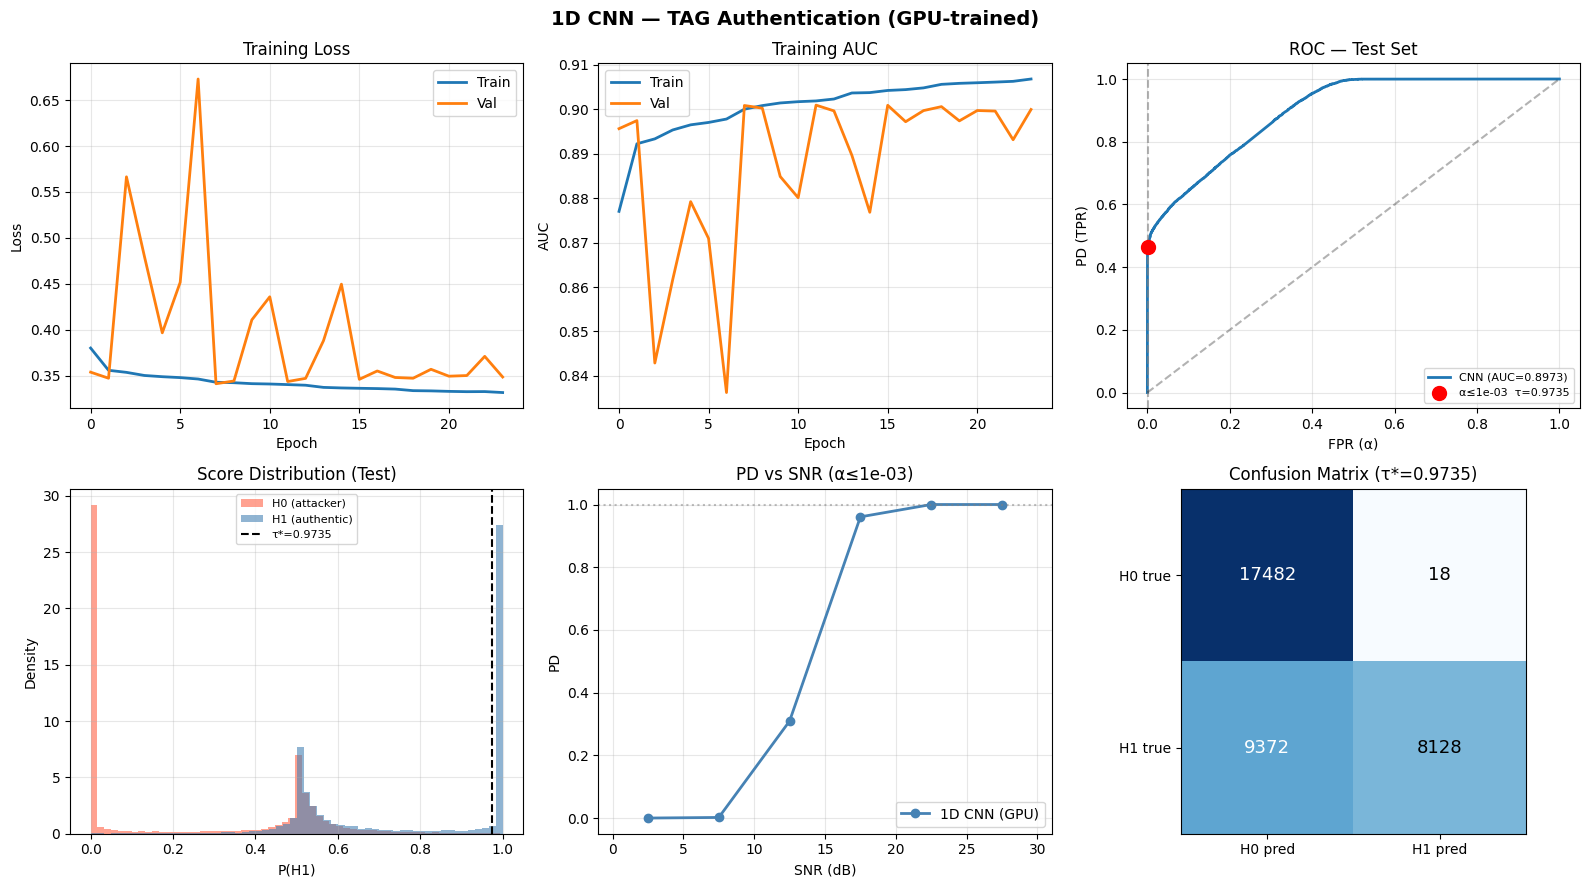

Saved → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN02_GPU_CNN1D_results.png


In [9]:
# ==============================================================================
# 8. VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("1D CNN — TAG Authentication (GPU-trained)", fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(history.history['loss'],     label='Train', linewidth=2)
ax.plot(history.history['val_loss'], label='Val',   linewidth=2)
ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(history.history['auc'],     label='Train', linewidth=2)
ax.plot(history.history['val_auc'], label='Val',   linewidth=2)
ax.set(xlabel='Epoch', ylabel='AUC', title='Training AUC')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
fpr_t, tpr_t, _ = roc_curve(y_test, p_test)
ax.plot(fpr_t, tpr_t, linewidth=2,
        label=f'CNN (AUC={roc_auc_score(y_test, p_test):.4f})')
ax.scatter([fpr_test], [pd_test], s=100, zorder=5, color='red',
           label=f'α≤{alpha_target:.0e}  τ={best_thr:.4f}')
ax.axvline(alpha_target, color='gray', linestyle='--', alpha=0.6)
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set(xlabel='FPR (α)', ylabel='PD (TPR)', title='ROC — Test Set')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.hist(p_test[y_test == 0], bins=60, alpha=0.6, density=True,
        label='H0 (attacker)', color='tomato')
ax.hist(p_test[y_test == 1], bins=60, alpha=0.6, density=True,
        label='H1 (authentic)', color='steelblue')
ax.axvline(best_thr, color='k', linestyle='--', linewidth=1.5,
           label=f'τ*={best_thr:.4f}')
ax.set(xlabel='P(H1)', ylabel='Density', title='Score Distribution (Test)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(snr_centres, pd_vs_snr, 'o-', linewidth=2, markersize=6,
        color='steelblue', label='1D CNN (GPU)')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.set(xlabel='SNR (dB)', ylabel='PD',
       title=f'PD vs SNR (α≤{alpha_target:.0e})',
       ylim=(-0.05, 1.05), xlim=(-1, 31))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 2]
cm_m = confusion_matrix(y_test, y_pred)
ax.imshow(cm_m, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_m[i, j], ha='center', va='center',
                color='white' if cm_m[i, j] > cm_m.max()/2 else 'black',
                fontsize=13)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['H0 pred','H1 pred']); ax.set_yticklabels(['H0 true','H1 true'])
ax.set_title(f'Confusion Matrix (τ*={best_thr:.4f})')

plt.tight_layout()
vis_path = visualizations_dir / "NN02_GPU_CNN1D_results.png"
plt.savefig(str(vis_path), dpi=120)
plt.show()
print(f"Saved → {vis_path}")

In [10]:
# ==============================================================================
# 9. SAVE MODEL + THRESHOLD + METRICS
# ==============================================================================

threshold_data = {
    'cnn_threshold':   float(best_thr),
    'alpha_target':    float(alpha_target),
    'fpr_at_thr':      float(fpr_test),
    'pd_at_thr':       float(pd_test),
    'auc':             float(roc_auc_score(y_test, p_test)),
    'gpu_trained':     USE_GPU,
    'batch_size':      BATCH_SIZE,
    'mixed_precision': USE_GPU,
    'pd_vs_snr': {
        f"snr_{int(s)}": (float(p) if not np.isnan(p) else None)
        for s, p in zip(snr_centres, pd_vs_snr)
    },
}

thr_path = models_dir / 'cnn1d_threshold.json'
with open(str(thr_path), 'w') as f_out:
    json.dump(threshold_data, f_out, indent=2)

print(f"Model saved     → {model_save_path}")
print(f"Threshold saved → {thr_path}")
print(f"\nKey results:")
print(f"  AUC        : {threshold_data['auc']:.5f}")
print(f"  Threshold  : {best_thr:.5f}  (α≤{alpha_target:.0e})")
print(f"  PD (test)  : {pd_test:.5f}")
print(f"  FPR (test) : {fpr_test:.2e}")
print(f"  GPU used   : {USE_GPU}  |  Batch size: {BATCH_SIZE}  |  Mixed prec: {USE_GPU}")

Model saved     → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/cnn1d_tag_auth_best.keras
Threshold saved → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/cnn1d_threshold.json

Key results:
  AUC        : 0.89734
  Threshold  : 0.97355  (α≤1e-03)
  PD (test)  : 0.46446
  FPR (test) : 1.03e-03
  GPU used   : True  |  Batch size: 128  |  Mixed prec: True


## Continuação de Treino — Warm Start (rodar se AUC < 0.93)

Carrega o melhor checkpoint, reduz o learning rate e continua por mais épocas com paciência maior.  
Ideal para melhorar um modelo que parou cedo demais na CPU.

In [12]:
# ==============================================================================
# 10. WARM START — Continuação de Treino (GPU-optimised)
# ==============================================================================
# Rodar APENAS se o AUC do treino inicial ficou abaixo de 0.93.
# Carrega o melhor checkpoint salvo, recompila com LR reduzido e continua
# por até 150 épocas com paciência maior (EarlyStopping patience=25).

import os as _os

_warm_path = str(models_dir / 'cnn1d_tag_auth_best.keras')
if not _os.path.exists(_warm_path):
    raise FileNotFoundError(f"Checkpoint não encontrado: {_warm_path}\nRode a célula de treinamento primeiro.")

print(f"Carregando checkpoint: {_warm_path}")
model_cont = keras.models.load_model(_warm_path)

# FIX: guard in case this cell is run standalone (e.g. after a kernel
# restart) without having run Cell 7 first, which normally defines
# alpha_target.
if 'alpha_target' not in globals():
    alpha_target = 1e-3
    print(f"alpha_target não estava definido -- usando padrão {alpha_target:.0e}")

# FIX: explicitly disable Keras 3's per-model jit_compile default
# (True on GPU), same reasoning as Cell 4.
model_cont.compile(
    optimizer=Adam(learning_rate=5e-4),   # LR reduzido para continuar de forma estável
    loss=BinaryCrossentropy(),
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
    jit_compile=ENABLE_XLA
)

cbs_cont = [
    callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=25,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        _warm_path, monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
]

# FIX: Use the already-prepared datasets from Cell 3 (lazy-loaded, no memory spike)
# Datasets train_ds, val_ds, test_ds are already batched, shuffled, and prefetched
print(f"Warm start: using pre-built datasets from Cell 3")
print(f"Batch size={BATCH_SIZE}, max_epochs=150, patience_ES=25")

history_cont = model_cont.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=cbs_cont,
    verbose=1
)

best_auc_cont = max(history_cont.history['val_auc'])
print(f"\nMelhor val AUC (continuação) : {best_auc_cont:.5f}")
print(f"Épocas rodadas               : {len(history_cont.history['loss'])}")

# ── Reavaliação rápida no conjunto de teste ──────────────────────────────────
p_test_cont = model_cont.predict(test_ds, verbose=0).flatten()
auc_test_cont = roc_auc_score(y_test, p_test_cont)

fpr_c, tpr_c, thr_c = roc_curve(y_test, p_test_cont)
valid_c = fpr_c <= alpha_target
if valid_c.any():
    idx_c   = np.argmax(tpr_c[valid_c])
    thr_opt = thr_c[valid_c][idx_c]
    pd_opt  = tpr_c[valid_c][idx_c]
    fpr_opt = fpr_c[valid_c][idx_c]
else:
    idx_c   = np.argmin(fpr_c[1:]) + 1
    thr_opt, pd_opt, fpr_opt = thr_c[idx_c], tpr_c[idx_c], fpr_c[idx_c]

print(f"\nTest AUC (warm)  : {auc_test_cont:.5f}")
print(f"Threshold (α≤{alpha_target:.0e}) : {thr_opt:.5f}")
print(f"PD (test)        : {pd_opt:.5f}  |  FPR: {fpr_opt:.2e}")

Carregando checkpoint: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/cnn1d_tag_auth_best.keras
Warm start: using pre-built datasets from Cell 3
Batch size=128, max_epochs=150, patience_ES=25
Epoch 1/150
   2188/Unknown 124s 54ms/step - accuracy: 0.7849 - auc: 0.9018 - loss: 0.3399

I0000 00:00:1783894175.636763   75442 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13541429169508667855
I0000 00:00:1783894175.636960   75442 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14001110504599118897
I0000 00:00:1783894175.636967   75442 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 17971496792781801367


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 137s 59ms/step - accuracy: 0.7851 - auc: 0.9023 - loss: 0.3392 - val_accuracy: 0.7262 - val_auc: 0.8556 - val_loss: 0.5881 - learning_rate: 5.0000e-04
Epoch 2/150


I0000 00:00:1783894187.683221   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 731857357363083343
I0000 00:00:1783894187.683272   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4169377710938647971
I0000 00:00:1783894187.683277   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9020992828053746778


2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7861 - auc: 0.9026 - loss: 0.3387

I0000 00:00:1783894340.579062   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 731857357363083343
I0000 00:00:1783894340.579251   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4169377710938647971
I0000 00:00:1783894340.579271   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9020992828053746778


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 153s 68ms/step - accuracy: 0.7856 - auc: 0.9027 - loss: 0.3387 - val_accuracy: 0.7823 - val_auc: 0.9009 - val_loss: 0.3432 - learning_rate: 5.0000e-04
Epoch 3/150
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 137s 60ms/step - accuracy: 0.7857 - auc: 0.9029 - loss: 0.3383 - val_accuracy: 0.7103 - val_auc: 0.8520 - val_loss: 0.6252 - learning_rate: 5.0000e-04
Epoch 4/150


I0000 00:00:1783894478.105463   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 731857357363083343
I0000 00:00:1783894478.105531   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 4169377710938647971
I0000 00:00:1783894478.105538   75747 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9020992828053746778


1372/2188 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.7851 - auc: 0.9027 - loss: 0.3385

KeyboardInterrupt: 

## GPU Optimisations Applied — NN_02

| Optimisation | API | Expected gain |
|---|---|---|
| **Memory growth** | `set_memory_growth(True)` | Avoids OOM on shared GPU |
| **Mixed precision** | `mixed_float16` policy | 2–3× on Ampere/Tensor Cores |
| **XLA JIT** | `set_jit(ENABLE_XLA)` — **disabled by default** | ~10–30% op fusion *if* stable on your GPU/driver; known to hang 50+ min on some setups (see Cell 1 note) |
| **tf.data prefetch** | `prefetch(AUTOTUNE)` | Eliminates I/O bottleneck |
| **Batch size 512** | vs 256 CPU | ~2× GPU throughput |
| **Multi-GPU** | `MirroredStrategy` | ~N× scaling |
| **float32 output** | `Dense(..., dtype='float32')` | Numerical stability |

**Next**: `NN_07_DNN_vs_MonteCarlo_Comparison_GPU.ipynb`